# 9. Drop-Off Analysis


> **Dataset note:** This project uses a synthetic OTT viewer-behaviour dataset for educational analysis.  
> **Hotstar is used only as the business case/scenario; the data is not claimed to be proprietary Hotstar data.**

**Allowed tools:** Python, NumPy, Pandas, Matplotlib, Seaborn.  
**Not used:** Scikit-learn, Plotly, Power BI, Tableau, machine learning, or statistical libraries beyond NumPy/Pandas.

## Process Performed
I measured overall and genre-level drop-off, examined episode-number patterns, tested the watch-completion relationship, and flagged episodes that deserve investigation.

In [1]:
# PROCESS: Load the CSV into a Pandas DataFrame and verify that the file loaded correctly.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DATA_PATH = "ott_viewer_dropoff_retention_us_v1.0.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (33171, 23)


,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,dialogue_density,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,high,5,39,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,low,8,55,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,high,7,46,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,medium,3,50,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,low,4,35,3,0,1,7,high,0,1,0.638,high,v1.0


## Overall Drop-Off

In [2]:
# KERNEL-SAFE SETUP
# Keep plotting memory controlled while preserving the analysis.
import gc

MAX_PLOT_ROWS = 5000

def safe_sample(data, n=MAX_PLOT_ROWS, random_state=42):
    """Use the full data when small; otherwise use a reproducible sample for plotting."""
    return data if len(data) <= n else data.sample(n=n, random_state=random_state)

def finish_plot():
    """Render and release the current Matplotlib figure."""
    plt.tight_layout()
    plt.show()
    plt.close()
    gc.collect()

In [3]:
# PROCESS: Perform this analysis step and inspect the resulting table/output before drawing conclusions.
print("Overall drop-off rate (%):", round(df["drop_off"].mean() * 100, 2))
print("Average drop-off probability:", round(df["drop_off_probability"].mean(), 3))

Overall drop-off rate (%): 14.48
Average drop-off probability: 0.478


## Drop-Off by Genre

In [4]:
# PROCESS: Group episode-level records by genre and compare the requested performance metric.
genre_dropoff = (
    df.groupby("genre")
    .agg(
        episodes=("show_id", "size"),
        drop_off_rate=("drop_off", "mean"),
        avg_drop_off_probability=("drop_off_probability", "mean")
    )
    .reset_index()
)
genre_dropoff["drop_off_rate_pct"] = genre_dropoff["drop_off_rate"] * 100
genre_dropoff = genre_dropoff.sort_values("drop_off_rate_pct", ascending=False)
display(genre_dropoff)

,genre,episodes,drop_off_rate,avg_drop_off_probability,drop_off_rate_pct
5,Drama,6142,0.241941,0.514758,24.194074
8,Mystery,233,0.188841,0.501219,18.884120
15,Western,71,0.183099,0.498056,18.309859
4,Documentary,75,0.173333,0.479213,17.333333
3,Crime,926,0.158747,0.476198,15.874730
14,War & Politics,51,0.156863,0.498039,15.686275
10,Reality,4005,0.135581,0.478437,13.558052
1,Animation,10028,0.134822,0.476837,13.482250
12,Soap,334,0.131737,0.476847,13.173653
13,Talk,2074,0.131630,0.475353,13.162970


## Drop-Off by Episode Number

,episode_number,episodes,drop_off_rate,avg_drop_off_probability,avg_watch,drop_off_rate_pct
0,1,500,0.036000,0.412126,64.942000,3.600000
1,2,497,0.179074,0.482139,56.305835,17.907445
2,3,492,0.140244,0.481374,56.343496,14.024390
3,4,487,0.162218,0.480963,56.410678,16.221766
4,5,484,0.154959,0.487494,55.723140,15.495868
5,6,479,0.167015,0.483610,56.050104,16.701461
6,7,456,0.168860,0.488007,56.061404,16.885965
7,8,445,0.182022,0.484461,55.907865,18.202247
8,9,395,0.146835,0.476365,56.812658,14.683544
9,10,378,0.153439,0.476749,56.997354,15.343915


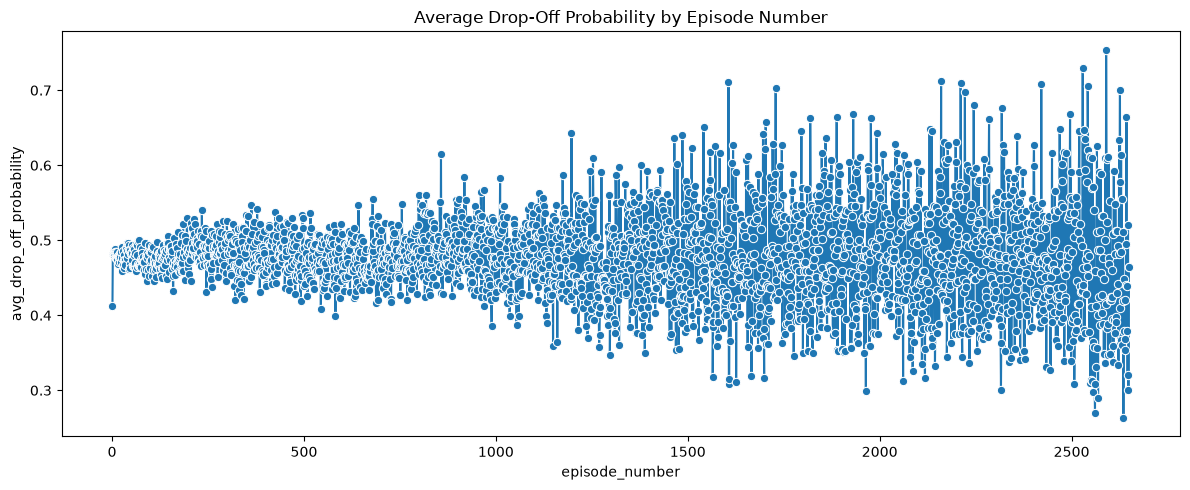

In [5]:
# PROCESS: Visualize the summarized relationship so patterns are easier to interpret.
episode_dropoff = (
    df.groupby("episode_number")
    .agg(
        episodes=("show_id", "size"),
        drop_off_rate=("drop_off", "mean"),
        avg_drop_off_probability=("drop_off_probability", "mean"),
        avg_watch=("avg_watch_percentage", "mean")
    )
    .reset_index()
    .sort_values("episode_number")
)
episode_dropoff["drop_off_rate_pct"] = episode_dropoff["drop_off_rate"] * 100
display(episode_dropoff.head(30))

plt.figure(figsize=(12, 5))
sns.lineplot(data=episode_dropoff, x="episode_number",
             y="avg_drop_off_probability", marker="o")
plt.title("Average Drop-Off Probability by Episode Number")
plt.tight_layout()
plt.show()
plt.close()

## Watch Completion vs Drop-Off Probability

Correlation between watch percentage and drop-off probability: -0.9573


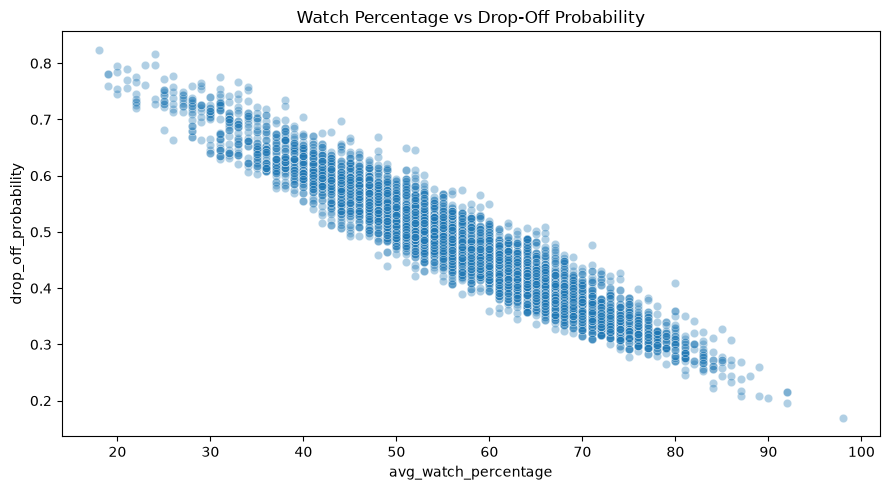

In [6]:
# PROCESS: Measure linear association with Pandas correlation; interpret association, not causation.
corr = df["avg_watch_percentage"].corr(df["drop_off_probability"])
print("Correlation between watch percentage and drop-off probability:", round(corr, 4))

plt.figure(figsize=(9, 5))
sample_df = df.sample(min(5000, len(df)), random_state=42)
sns.scatterplot(
    data=sample_df,
    x="avg_watch_percentage",
    y="drop_off_probability",
    alpha=0.35
)
plt.title("Watch Percentage vs Drop-Off Probability")
plt.tight_layout()
plt.show()
plt.close()

## Episodes Requiring Investigation

In [7]:
# PROCESS: Use dataset-relative quantile thresholds instead of arbitrary cut-offs for prioritization.
# Flag episodes with both high modeled drop-off probability and low watch completion.
# Quantiles make the rule relative to the dataset rather than using arbitrary cutoffs.
high_drop_threshold = df["drop_off_probability"].quantile(0.90)
low_watch_threshold = df["avg_watch_percentage"].quantile(0.25)

investigation = (
    df[
        (df["drop_off_probability"] >= high_drop_threshold) &
        (df["avg_watch_percentage"] <= low_watch_threshold)
    ]
    [["title", "season_number", "episode_number", "genre",
      "avg_watch_percentage", "drop_off_probability",
      "hook_strength", "pacing_score", "cognitive_load",
      "retention_risk"]]
    .sort_values(["drop_off_probability", "avg_watch_percentage"],
                 ascending=[False, True])
)

print("High drop-off threshold:", round(high_drop_threshold, 3))
print("Low watch threshold:", round(low_watch_threshold, 2))
display(investigation.head(20))

High drop-off threshold: 0.622
Low watch threshold: 48.0


,title,season_number,episode_number,genre,avg_watch_percentage,drop_off_probability,hook_strength,pacing_score,cognitive_load,retention_risk
20822,Blood Flowers,1,42,Drama,21,0.831,3,4,9,high
6280,Doraemon,1,1259,Action & Adventure,18,0.824,3,4,9,high
21860,Pleasant Goat and Big Big Wolf,1,510,Animation,23,0.822,3,4,9,high
15252,A Kindred Spirit,1,1113,Drama,21,0.821,3,4,9,high
31170,Show! Music Core,1,762,Reality,24,0.817,3,4,9,high
14403,A Kindred Spirit,1,264,Drama,20,0.815,3,3,9,high
31394,Station 19,1,5,Drama,16,0.813,3,3,9,high
25255,This Is Us,1,6,Drama,23,0.811,3,4,9,high
32169,CID,1,623,Action & Adventure,19,0.809,3,4,9,high
10680,Sazae-san,1,2160,Animation,15,0.808,3,4,9,high


### Interpretation Note
The outputs above describe patterns in the supplied **synthetic episode-level dataset**. They should support business hypotheses and content investigation, not be presented as causal proof or proprietary Hotstar findings.

## Key Interpretation

Watch percentage and drop-off probability show a very strong inverse relationship (**r ≈ -0.957**). Episodes with low completion and high drop-off probability are therefore the clearest investigation candidates, although this remains an association rather than causal proof.

In [8]:
# KERNEL-SAFE CLEANUP
plt.close('all')
gc.collect()
print('Notebook cleanup complete.')

Notebook cleanup complete.
